In [3]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from itertools import product
import gc

import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder

In [4]:
sales_train = pd.read_csv("data/sales_train.csv")
shops = pd.read_csv("data/shops.csv")
items = pd.read_csv("data/items.csv")
item_categories = pd.read_csv("data/item_categories.csv")
test = pd.read_csv("data/test.csv")
submission = pd.read_csv("submission/sample_submission.csv")

# 1. Exploratory Data Analysis

In [5]:
sales_train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


- The `date_block_num` feature serves as a date identifier. Sequentially, 0 represents January 2013, 1 represents February 2013, and 33 represents October 2015.
- Since the competition's target value is to predict monthly sales, only a monthly identifier is required. Therefore, the `date_block_num` feature alone is sufficient. So I will drop `date` feature.

- The `item_cnt_day feature` represents daily sales, with the first row showing a value of 1.0. This indicates that on January 2, 2013, store ID 59 sold 1 unit of item ID 22154. However, this does not correspond to the target value, which is "monthly" sales.
- To compute the target value, I will group by the `date_block_num` feature and sum the `item_cnt_day` values to create the monthly sales target.

- The training data contains sales records from January 2013 to October 2015, arranged in chronological order. Since the time flow is crucial for time series data, I will use data up to September 2015 as the training set and reserve October 2015 as the validation set.

In [6]:
sales_train.info(show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            2935849 non-null  object 
 1   date_block_num  2935849 non-null  int64  
 2   shop_id         2935849 non-null  int64  
 3   item_id         2935849 non-null  int64  
 4   item_price      2935849 non-null  float64
 5   item_cnt_day    2935849 non-null  float64
dtypes: float64(2), int64(3), object(1)
memory usage: 134.4+ MB


- There is no null data in this dataset.
- The size of data is almost 3 millions, which is pretty large to take heavy memory usage.

In [7]:
shops.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


- The shop_name is in russian. I can't understand russian at this point, but we have other fellows who can speak russian.
- The first word of the shop name represents the city name where the shop is located.
- I will extract only the first word of the shop_name and make a new feature.
- The shop_id feature is also present in the sales_train dataset. Therefore, it is possible to merge the datasets using shop_id as the key.

In [8]:
shops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   shop_name  60 non-null     object
 1   shop_id    60 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


- Only 60 shops
- No null data
- Less memoy usage
- No problem here

In [9]:
items.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


- It is also written in russian.
- Since there is no critical information within the `item_name` feature, I will drop it.
- The item_id feature is also present in the sales_train dataset. So, I will merge the datasets using item_id as the key.

In [10]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22170 entries, 0 to 22169
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   item_name         22170 non-null  object
 1   item_id           22170 non-null  int64 
 2   item_category_id  22170 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 519.7+ KB


- No null data


In [11]:
item_categories.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


- I can merge the datasets using the item_category_id as the key.
- The first word in the name represent the item category, which means that I could revise the feature that only include item_category name.

In [12]:
item_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   item_category_name  84 non-null     object
 1   item_category_id    84 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.4+ KB


- No null data
- 84 item categories

### 1.1 Data merge

In [13]:
train = sales_train.merge(shops, on = "shop_id", how = "left")
train = train.merge(items, on = "item_id", how = "left")
train = train.merge(item_categories, on = "item_category_id", how = "left")

train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,shop_name,item_name,item_category_id,item_category_name
0,02.01.2013,0,59,22154,999.00,1.0,"Ярославль ТЦ ""Альтаир""",ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray
1,03.01.2013,0,25,2552,899.00,1.0,"Москва ТРК ""Атриум""",DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил
2,05.01.2013,0,25,2552,899.00,-1.0,"Москва ТРК ""Атриум""",DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил
3,06.01.2013,0,25,2554,1709.05,1.0,"Москва ТРК ""Атриум""",DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил
4,15.01.2013,0,25,2555,1099.00,1.0,"Москва ТРК ""Атриум""",DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства


In [14]:
def resumetable(df):
    print(f"data shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes, columns = ['data type'])
    summary = summary.reset_index()
    summary = summary.rename(columns = {"index": "feature"})
    summary["Num_Null"] = df.isnull().sum().values
    summary["Num_Unique"] = df.nunique().values
    summary["First_Value"] = df.loc[0].values
    summary["Second_Value"] = df.loc[1].values
    summary["Third_Value"] = df.loc[2].values
    
    return summary

resumetable(train)

data shape: (2935849, 10)


,feature,data type,Num_Null,Num_Unique,First_Value,Second_Value,Third_Value
0,date,object,0,1034,02.01.2013,03.01.2013,05.01.2013
1,date_block_num,int64,0,34,0,0,0
2,shop_id,int64,0,60,59,25,25
3,item_id,int64,0,21807,22154,2552,2552
4,item_price,float64,0,19993,999.0,899.0,899.0
5,item_cnt_day,float64,0,198,1.0,1.0,-1.0
6,shop_name,object,0,60,"Ярославль ТЦ ""Альтаир""","Москва ТРК ""Атриум""","Москва ТРК ""Атриум"""
7,item_name,object,0,21807,ЯВЛЕНИЕ 2012 (BD),DEEP PURPLE The House Of Blue Light LP,DEEP PURPLE The House Of Blue Light LP
8,item_category_id,int64,0,84,37,58,58
9,item_category_name,object,0,84,Кино - Blu-Ray,Музыка - Винил,Музыка - Винил


- No null data
- Since `shop_id`, `item_id`, and `item_category_id` each have a one-to-one correspondence with `shop_name`, `item_name`, and `item_category_name`, respectively, one of each pair should be removed to avoid redundancy.

### 1.2 Data Visualization

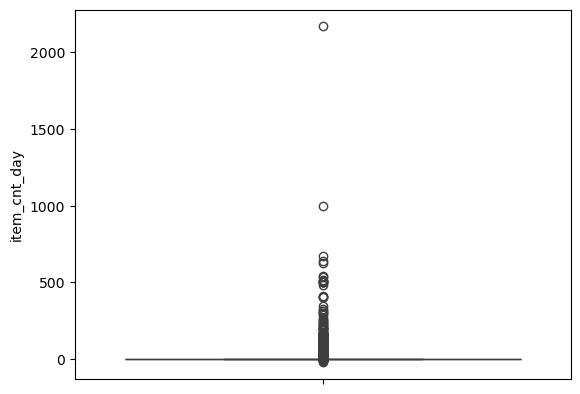

In [15]:
# Sales per day

sns.boxplot(y = "item_cnt_day", data = train);

- The shape of the box plot seems little bit weird. It is because of outliers.
- The range of outliers is super wide. So I have to eliminate the extreme outliers first.

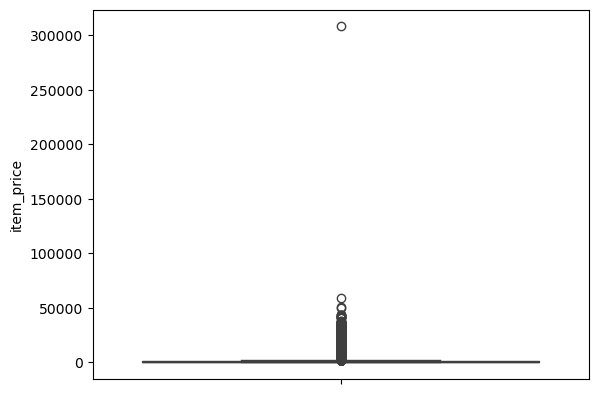

In [16]:
# Item price

sns.boxplot(y = "item_price", data = train);

- This box plot also has a flat shape, indicating the presence of outliers. It seems necessary to remove outliers.

In [17]:
group = train.groupby("date_block_num").agg({"item_cnt_day": "sum"})
group.reset_index()

,date_block_num,item_cnt_day
0,0,131479.0
1,1,128090.0
2,2,147142.0
3,3,107190.0
4,4,106970.0
5,5,125381.0
6,6,116966.0
7,7,125291.0
8,8,133332.0
9,9,127541.0


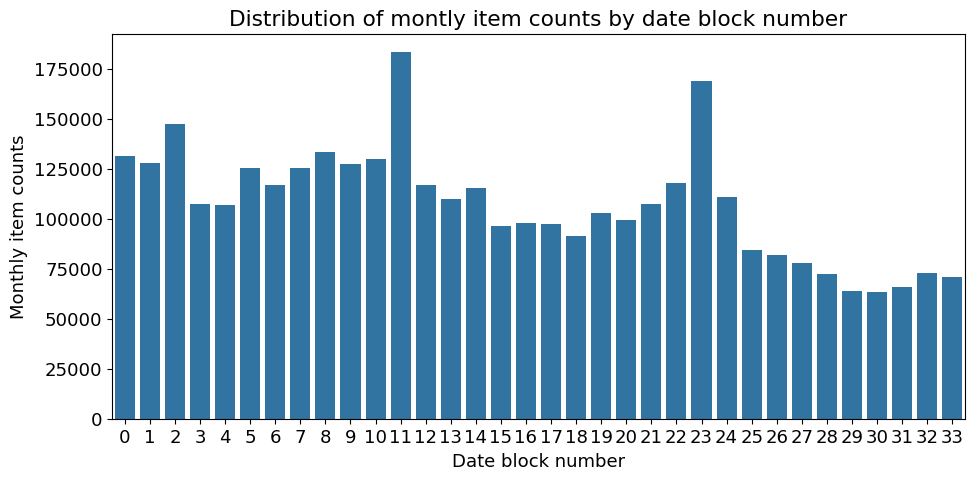

In [18]:
# Sales per month

mpl.rc("font", size = 13)
figure, ax = plt.subplots()
figure.set_size_inches(11, 5)

group_month_sum = train.groupby("date_block_num").agg({"item_cnt_day": "sum"}).reset_index()

sns.barplot(x = "date_block_num", y = "item_cnt_day", data = group_month_sum)
ax.set(title = "Distribution of montly item counts by date block number",
       xlabel = "Date block number",
       ylabel = "Monthly item counts");

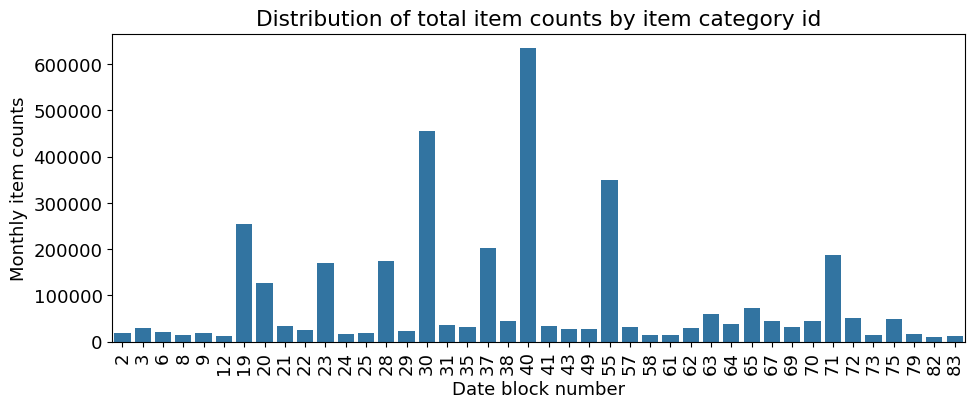

In [19]:
# Sales per item category

figure, ax = plt.subplots()
figure.set_size_inches(11, 4)

# Total sales by item category
group_cat_sum = train.groupby("item_category_id").agg({"item_cnt_day": "sum"}).reset_index()
group_cat_sum = group_cat_sum[group_cat_sum["item_cnt_day"] > 10000]

sns.barplot(x = "item_category_id", y = "item_cnt_day", data = group_cat_sum)
ax.set(title = "Distribution of total item counts by item category id",
       xlabel = "Date block number",
       ylabel = "Monthly item counts");
ax.tick_params(axis = "x", labelrotation = 90)

- It can be observed that category ID 40 has the highest sales, followed by categories 30 and 55. This indicates that certain item categories sell significantly more than others.

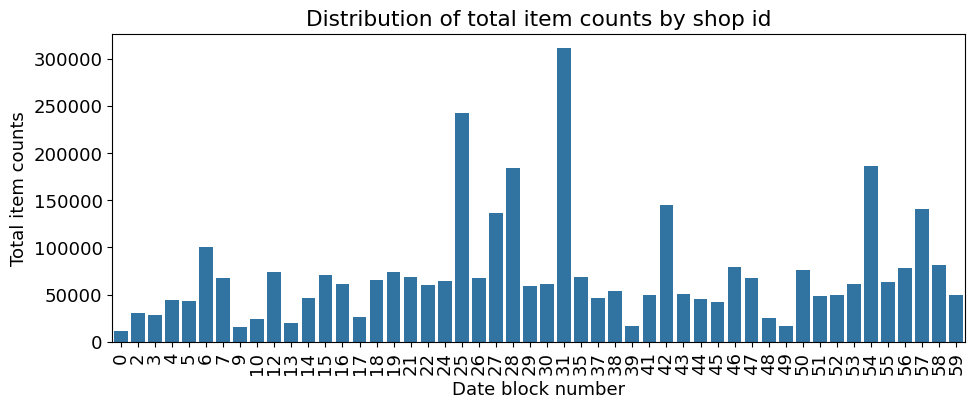

In [20]:
# Monthly sales by store

figure, ax = plt.subplots()
figure.set_size_inches(11, 4)

group_shop_sum = train.groupby("shop_id").agg({"item_cnt_day": "sum"}).reset_index()
group_shop_sum = group_shop_sum[group_shop_sum["item_cnt_day"] > 10000]

sns.barplot(x = "shop_id", y = "item_cnt_day", data = group_shop_sum)
ax.set(title = "Distribution of total item counts by shop id",
       xlabel = "Date block number",
       ylabel = "Total item counts");
ax.tick_params(axis = "x", labelrotation = 90)

- Store ID 31 has sold the most products, followed by store ID 25. Around 7–8 stores show significantly higher sales compared to other stores.

# 2. Baseline Model

### 2.1 Feature Engineering (Data Downcasting)

- As mentioned earlier, the data size will increase after various feature engineering processes, making memory management essential.
- When data is loaded with pandas, integers are assigned the int64 and floats the float64  by default, which are the largest types for each. However, not all features need to use the maximum type, as this increases memory usage unnecessarily. For features with smaller numeric values, assigning smaller types will prevent memory waste and improve training speed.

In [21]:
def downcast(df, verbose = True):
    start_memory = df.memory_usage().sum() / 1024 ** 2
    for col in df.columns:
        dtype_name = df[col].dtype.name
        if dtype_name == "object":
            pass
        elif dtype_name == "bool":
            df[col] = df[col].astype("int8")
        elif dtype_name.startswith("int") or (df[col].round() == df[col]).all():
            df[col] = pd.to_numeric(df[col], downcast = "integer")
        else:
            df[col] = pd.to_numeric(df[col], downcast = "float")
    end_memory = df.memory_usage().sum() / 1024 ** 2

    if verbose:
        print("{:.1f}% compressed".format(100 * (start_memory - end_memory) / start_memory))

    return df

In [22]:
all_df = [sales_train, shops, items, item_categories, test]
for df in all_df:
    df = downcast(df)

54.2% compressed
38.5% compressed
54.2% compressed
39.8% compressed
70.8% compressed


### 2.2 Feature Engineering (second submission)

In [23]:
# eliminate outliers of sales_train

sales_train = sales_train[sales_train["item_price"] > 0]
sales_train = sales_train[sales_train["item_price"] < 50000]

sales_train = sales_train[sales_train["item_cnt_day"] > 0]
sales_train = sales_train[sales_train["item_cnt_day"] < 1000]

In [24]:
print(shops["shop_name"][0], "|", shops["shop_name"][57])
print(shops["shop_name"][1], "|", shops["shop_name"][58])
print(shops["shop_name"][10], "|", shops["shop_name"][11])
print(shops["shop_name"][39], "|", shops["shop_name"][40])

!Якутск Орджоникидзе, 56 фран | Якутск Орджоникидзе, 56
!Якутск ТЦ "Центральный" фран | Якутск ТЦ "Центральный"
Жуковский ул. Чкалова 39м? | Жуковский ул. Чкалова 39м²
РостовНаДону ТРК "Мегацентр Горизонт" | РостовНаДону ТРК "Мегацентр Горизонт" Островной


- There are four pairs of stores that are recorded separately due to slight variations in their store names, even though they are the same store.
- In both `sales_train` and `test` data, `item_id` 0 is modified to 57, 1 to 58, 10 to 11, and 39 to 30
- Because `shop_name` and `shop_id` have a one-to-one mapping, and since `shop_id` is string data, it will be removed later

In [25]:
sales_train.loc[sales_train["shop_id"] == 0, "shop_id"] = 57
sales_train.loc[sales_train["shop_id"] == 1, "shop_id"] = 58
sales_train.loc[sales_train["shop_id"] == 10, "shop_id"] = 11
sales_train.loc[sales_train["shop_id"] == 39, "shop_id"] = 40

test.loc[test["shop_id"] == 0, "shop_id"] = 57
test.loc[test["shop_id"] == 1, "shop_id"] = 58
test.loc[test["shop_id"] == 10, "shop_id"] = 11
test.loc[test["shop_id"] == 39, "shop_id"] = 40

In [26]:
shops["city"] = shops["shop_name"].apply(lambda x: x.split()[0])
shops["city"].unique()
shops.loc[shops["city"] == "!Якутск", "city"] = "Якутск"

- Thankfully, another Kaggler discovered that the first word of the store name refers to the city.
- But, city names are categorical feature. But it needs to be encoded so that my model can understand.

In [27]:
label_encoder = LabelEncoder()
shops["city"] = label_encoder.fit_transform(shops["city"])
shops = shops.drop("shop_name", axis = 1)
shops.head()

,shop_id,city
0,0,29
1,1,29
2,2,0
3,3,1
4,4,2


In [28]:
items = items.drop(["item_name"], axis = 1)

- The `item_name` feature is also in a one-to-one correspondence with `item_id`, so it can be removed.

In [29]:
sales_train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1
1,03.01.2013,0,25,2552,899.00,1
3,06.01.2013,0,25,2554,1709.05,1
4,15.01.2013,0,25,2555,1099.00,1
5,10.01.2013,0,25,2564,349.00,1


In [30]:
# Add a feature representing the first day a product was sold

items["first_sold_month"] = sales_train.groupby("item_id").agg({"date_block_num": "min"})["date_block_num"]

items.head()

,item_id,item_category_id,first_sold_month
0,0,40,20.0
1,1,76,15.0
2,2,40,19.0
3,3,40,18.0
4,4,40,20.0


In [31]:
items[items['first_sold_month'].isna()]

,item_id,item_category_id,first_sold_month
83,83,40,NaN
140,140,45,NaN
168,168,44,NaN
173,173,45,NaN
204,204,44,NaN
...,...,...,...
21974,21974,61,NaN
21975,21975,61,NaN
22022,22022,40,NaN
22035,22035,40,NaN


- There is 368 missing values.
- Here, missing values indicate that the product has never been sold.

- The training data contains sales records from January 2013 to October 2015, with month IDs ranging from 0 to 33. If a product was never sold during this period, it can be assumed that its first sale would occur in November 2015.
-Therefore, missing values in the "first month of sale" feature can be replaced with 34.
- Of course, it is possible that the product might not sell in November 2015 either, but that is not an issue.
- Such products are not included in the test data and are therefore not considered at all.
- The first month of sale for products not considered in the test data, whether it is 34 or another value, does not matter.

In [32]:
items['first_sold_month'] = items['first_sold_month'].fillna(34)

In [33]:
# Extract the first word of the item category name as the major category

item_categories["major_category"] = item_categories["item_category_name"].apply(lambda x: x.split()[0])
item_categories["major_category"].value_counts()

major_category
Игры          14
Книги         13
Подарки       12
Игровые        8
Аксессуары     7
Музыка         6
Программы      6
Карты          5
Кино           5
Служебные      2
Чистые         2
PC             1
Билеты         1
Доставка       1
Элементы       1
Name: count, dtype: int64

- Игры means 'Game'
- Книги means 'book'
- Подарки means 'gift'
- Replace major categories with fewer than 5 unique values with "etc"

In [34]:
def make_etc(x):
    if len(item_categories[item_categories["major_category"] == x]) >= 5:
        return x
    else:
        return "etc"

item_categories["major_category"] = item_categories["major_category"].apply(make_etc)
item_categories.head()

,item_category_name,item_category_id,major_category
0,PC - Гарнитуры/Наушники,0,etc
1,Аксессуары - PS2,1,Аксессуары
2,Аксессуары - PS3,2,Аксессуары
3,Аксессуары - PS4,3,Аксессуары
4,Аксессуары - PSP,4,Аксессуары


In [35]:
label_encoder = LabelEncoder()

item_categories["major_category"] = \
label_encoder.fit_transform(item_categories["major_category"])

item_categories = item_categories.drop("item_category_name", axis = 1)

### 2.3 Feature Engineering (create data combination) (second submission)

In [36]:
train = []

for i in sales_train["date_block_num"].unique():
    all_shop = sales_train.loc[sales_train["date_block_num"] == i, "shop_id"].unique()
    all_item = sales_train.loc[sales_train["date_block_num"] == i, "item_id"].unique()
    train.append(np.array(list(product([i], all_shop, all_item))))


idx_features = ["date_block_num", "shop_id", "item_id"]

train = pd.DataFrame(np.vstack(train), columns = idx_features)

In [37]:
group = sales_train.groupby(idx_features).agg({"item_cnt_day": "sum", 
                                               "item_price": "mean"})
group = group.reset_index().rename(columns = {"item_cnt_day": "monthly_sales",
                                              "item_price": "avg_price"})

In [38]:
train = train.merge(group, on = idx_features, how = "left")
train.head()

,date_block_num,shop_id,item_id,monthly_sales,avg_price
0,0,59,22154,1.0,999.0
1,0,59,2552,NaN,NaN
2,0,59,2554,NaN,NaN
3,0,59,2555,NaN,NaN
4,0,59,2564,NaN,NaN


- Unlike the first submission, a new derived feature, average selling price, has been added.
- However, there are missing values, which indicate that both sales and selling price are 0. Missing values will be replaced with 0.

In [39]:
del group
gc.collect();

In [40]:
group = sales_train.groupby(idx_features).agg({"item_cnt_day": "count"}).reset_index().rename(columns = {"item_cnt_day": "num_transaction"})

train = train.merge(group, on = idx_features, how = "left")

In [41]:
del group, sales_train
gc.collect()

train.head()

,date_block_num,shop_id,item_id,monthly_sales,avg_price,num_transaction
0,0,59,22154,1.0,999.0,1.0
1,0,59,2552,NaN,NaN,NaN
2,0,59,2554,NaN,NaN,NaN
3,0,59,2555,NaN,NaN,NaN
4,0,59,2564,NaN,NaN,NaN


### 2.4 Feature Engineering (merge test data) (second submssion)

In [42]:
test["date_block_num"] = 34

all_data = pd.concat([train, test.drop("ID", axis = 1)], # ID feature is useless feature so need to be dropped
                     ignore_index = True,  
                     keys = idx_features)

all_data = all_data.fillna(0)
all_data

/var/folders/zg/x68_g2m16d54j5p0wq1p2f900000gn/T/ipykernel_47112/482332884.py:3: FutureWarning: The behavior of pd.concat with len(keys) != len(objs) is deprecated. In a future version this will raise instead of truncating to the smaller of the two sequences
  all_data = pd.concat([train, test.drop("ID", axis = 1)], # ID feature is useless feature so need to be dropped


,date_block_num,shop_id,item_id,monthly_sales,avg_price,num_transaction
0,0,59,22154,1.0,999.0,1.0
1,0,59,2552,0.0,0.0,0.0
2,0,59,2554,0.0,0.0,0.0
3,0,59,2555,0.0,0.0,0.0
4,0,59,2564,0.0,0.0,0.0
...,...,...,...,...,...,...
11026963,34,45,18454,0.0,0.0,0.0
11026964,34,45,16188,0.0,0.0,0.0
11026965,34,45,15757,0.0,0.0,0.0
11026966,34,45,19648,0.0,0.0,0.0


### 2.5 Feature Engineering (finialize dataset)

In [43]:
all_data = all_data.merge(shops, on = "shop_id", how = "left")
all_data = all_data.merge(items, on = "item_id", how = "left")
all_data = all_data.merge(item_categories, on = "item_category_id", how = "left")

all_data = downcast(all_data)

68.9% compressed


In [44]:
del shops, items, item_categories
gc.collect();

In [45]:
# all_data = all_data.drop(["shop_name", "item_name", "item_category_name"], axis = 1)
# all_data = all_data.rename(columns = {"date_block_num": "month_id"}) 
# all_data

In [46]:
# X_train = all_data[all_data["month_id"] < 33]
# X_train = X_train.drop(["month_id"], axis = 1)

# X_valid = all_data[all_data["month_id"] == 33]
# X_valid = X_valid.drop(["month_id"], axis = 1)

# X_test = all_data[all_data["month_id"] == 34]
# X_test = X_test.drop(["month_id"], axis = 1)

# y_train = all_data[all_data["month_id"] < 33]["monthly_sales"]
# y_train = y_train.clip(0, 20)

# y_valid = all_data[all_data["month_id"] == 33]["monthly_sales"]
# y_valid = y_valid.clip(0, 20)

In [47]:
# del all_data
# gc.collect();

### 2.6 Feature engineering (create time lag feature)

In [48]:
def add_mean_features(df, mean_features, idx_features):
    assert (idx_features[0] == "date_block_num") and \
        len(idx_features) in [2, 3]

    if len(idx_features) == 2:
        feature_name = f"Average sales by {idx_features[1]}"
    else:
        feature_name = f"Average sales by {idx_features[1]} and {idx_features[2]}"

    group = df.groupby(idx_features).agg({"monthly_sales": "mean"}).reset_index().rename(columns = {'monthly_sales': feature_name})

    df = df.merge(group, on = idx_features, how = "left")
    df = downcast(df, verbose = False)
    mean_features.append(feature_name)

    del group
    gc.collect()

    return df, mean_features

In [49]:
item_mean_features = []

# Create a feature for the monthly average sales grouped by date_block_num and item_id
all_data, item_mean_features = add_mean_features(df = all_data, 
                                                 mean_features = item_mean_features,
                                                 idx_features = ["date_block_num", "item_id"])

# Create a feature for the monthly average sales grouped by date_block_num, item_id, and city 
all_data, item_mean_features = add_mean_features(df = all_data, 
                                                 mean_features = item_mean_features,
                                                 idx_features = ["date_block_num", "item_id", "city"])

In [50]:
item_mean_features

['Average sales by item_id', 'Average sales by item_id and city']

In [51]:
shop_mean_features = []

# Create a feature for the monthly average sales grouped by date_block_num, item_id, and item_category_id

all_data, shop_mean_features = add_mean_features(df = all_data, 
                                                 mean_features = shop_mean_features,
                                                 idx_features = ["date_block_num", "shop_id", "item_category_id"])

shop_mean_features

['Average sales by shop_id and item_category_id']

In [52]:
def add_lag_features(df, lag_features_to_clip, idx_features, lag_feature, nlags = 3, clip = False):
    df_temp = df[idx_features + [lag_feature]].copy()
    for i in range(1, nlags + 1):
        lag_feature_name = lag_feature + "_lag" + str(i)
        df_temp.columns = idx_features + [lag_feature_name]
        df_temp["date_block_num"] += 1
        df = df.merge(df_temp.drop_duplicates(), on = idx_features, how = "left")
        df[lag_feature_name] = df[lag_feature_name].fillna(0)
        if clip:
            lag_features_to_clip.append(lag_feature_name)

    df = downcast(df, False)
    del df_temp
    gc.collect()

    return df, lag_features_to_clip

In [53]:
lag_features_to_clip = []
all_data, lag_features_to_clip = add_lag_features(df = all_data, 
                                                 lag_features_to_clip = lag_features_to_clip,
                                                 idx_features = idx_features,
                                                lag_feature = "monthly_sales",
                                                nlags = 3,
                                                clip = True)

In [54]:
all_data.head().T

,0,1,2,3,4
date_block_num,0.000000,0.000000,0.000000,0.000000,0.000000
shop_id,59.000000,59.000000,59.000000,59.000000,59.000000
item_id,22154.000000,2552.000000,2554.000000,2555.000000,2564.000000
monthly_sales,1.000000,0.000000,0.000000,0.000000,0.000000
avg_price,999.000000,0.000000,0.000000,0.000000,0.000000
num_transaction,1.000000,0.000000,0.000000,0.000000,0.000000
city,30.000000,30.000000,30.000000,30.000000,30.000000
item_category_id,37.000000,58.000000,58.000000,56.000000,59.000000
first_sold_month,0.000000,0.000000,0.000000,0.000000,0.000000
major_category,5.000000,7.000000,7.000000,7.000000,7.000000


In [55]:
# Create a three month lag feature for the num_transaction based on idx_features

all_data, lag_features_to_clip = add_lag_features(df = all_data, 
                                                 lag_features_to_clip = lag_features_to_clip,
                                                 idx_features = idx_features,
                                                lag_feature = "num_transaction",
                                                nlags = 3)

# Create a three-month lag feature for the avg_price column based on idx_features
all_data, lag_features_to_clip = add_lag_features(df = all_data, 
                                                 lag_features_to_clip = lag_features_to_clip,
                                                 idx_features = idx_features,
                                                lag_feature = "avg_price",
                                                nlags = 3)

In [56]:
# Create lag features for each element in item_mean_features based on idx_features

for item_mean_feature in item_mean_features:
    all_data, lag_features_to_clip = add_lag_features(df = all_data, 
                                                 lag_features_to_clip = lag_features_to_clip,
                                                 idx_features = idx_features,
                                                lag_feature = item_mean_feature,
                                                nlags = 3,
                                                     clip = True)

all_data = all_data.drop(item_mean_features, axis = 1)

In [57]:
# Create lag features for each element in shop_mean_features based on ["date_block_num", "shop_id", "item_category_id"]

for shop_mean_feature in shop_mean_features:
    all_data, lag_features_to_clip = add_lag_features(df = all_data, 
                                                      lag_features_to_clip = lag_features_to_clip,
                                                      idx_features = ["date_block_num", "shop_id", "item_category_id"], 
                                                      lag_feature = shop_mean_feature,
                                                      nlags = 3,
                                                      clip = True)

all_data = all_data.drop(shop_mean_features, axis = 1)

In [58]:
all_data = all_data.drop(all_data[all_data["date_block_num"] < 3].index)

### 2.6 Feature Engineering (Additional Feature Engineering)

In [59]:
all_data.columns

Index(['date_block_num', 'shop_id', 'item_id', 'monthly_sales', 'avg_price',
       'num_transaction', 'city', 'item_category_id', 'first_sold_month',
       'major_category', 'monthly_sales_lag1', 'monthly_sales_lag2',
       'monthly_sales_lag3', 'num_transaction_lag1', 'num_transaction_lag2',
       'num_transaction_lag3', 'avg_price_lag1', 'avg_price_lag2',
       'avg_price_lag3', 'Average sales by item_id_lag1',
       'Average sales by item_id_lag2', 'Average sales by item_id_lag3',
       'Average sales by item_id and city_lag1',
       'Average sales by item_id and city_lag2',
       'Average sales by item_id and city_lag3',
       'Average sales by shop_id and item_category_id_lag1',
       'Average sales by shop_id and item_category_id_lag2',
       'Average sales by shop_id and item_category_id_lag3'],
      dtype='object')

In [60]:
# Create "Monthly Sales Lagged Mean" feature

all_data["monthly_sales_lagged_mean"] = all_data[["monthly_sales_lag1", "monthly_sales_lag2", "monthly_sales_lag3"]].mean(axis = 1)

all_data[lag_features_to_clip + ["monthly_sales", "monthly_sales_lagged_mean"]] = \
all_data[lag_features_to_clip + ["monthly_sales", "monthly_sales_lagged_mean"]].clip(0, 20)

In [61]:
# Create "Lag Change" feature 1 and 2

all_data["lag_change_1"] = all_data["monthly_sales_lag1"] / all_data["monthly_sales_lag2"]
all_data["lag_change_1"] = all_data["lag_change_1"].replace([np.inf, -np.inf], np.nan).fillna(0)

all_data["lag_change_2"] = all_data["monthly_sales_lag2"] / all_data["monthly_sales_lag3"]
all_data["lag_change_2"] = all_data["lag_change_2"].replace([np.inf, -np.inf], np.nan).fillna(0)

In [62]:
# Create Brand new status feature

all_data["brand_new"] = all_data["first_sold_month"] == all_data["date_block_num"]

In [63]:
# Create "Period Since First Sale" feature

all_data["period_since_first_sale"] = all_data["date_block_num"] - all_data["first_sold_month"]

In [64]:
# Create month feature

all_data["month"] = all_data["date_block_num"] % 12

In [65]:
all_data = all_data.drop(["first_sold_month", "avg_price", "num_transaction"], axis = 1)
all_data = downcast(all_data, False)

In [66]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9904582 entries, 1122386 to 11026967
Data columns (total 31 columns):
 #   Column                                              Dtype  
---  ------                                              -----  
 0   date_block_num                                      int8   
 1   shop_id                                             int8   
 2   item_id                                             int16  
 3   monthly_sales                                       int8   
 4   city                                                int8   
 5   item_category_id                                    int8   
 6   major_category                                      int8   
 7   monthly_sales_lag1                                  int8   
 8   monthly_sales_lag2                                  int8   
 9   monthly_sales_lag3                                  int8   
 10  num_transaction_lag1                                int8   
 11  num_transaction_lag2          

- After long feature engineering, there are a total of 30 features. The monthly_sales feature is the target feature.
- Now, we have to split the data into train and test set

In [67]:
X_train = all_data[all_data["date_block_num"] < 33]
X_train = X_train.drop(["monthly_sales"], axis = 1)

X_valid = all_data[all_data["date_block_num"] == 33]
X_valid = X_valid.drop(["monthly_sales"], axis = 1)

X_test = all_data[all_data["date_block_num"] == 34]
X_test = X_test.drop(["monthly_sales"], axis = 1)

y_train = all_data[all_data["date_block_num"] < 33]["monthly_sales"]
y_valid = all_data[all_data["date_block_num"] == 33]["monthly_sales"]

In [68]:
del all_data
gc.collect();

# 3. Model training and evaluation

In [290]:
params = {"metric": "rmse",
          "num_leaves": 255,
          "learning_rate": 0.005,
          "feature_fraction": 0.75,
          "bagging_fraction": 0.75,
          "bagging_freq": 5,
          "force_col_wise": True,
          "seed": 42}

features = ["shop_id", "city", "item_category_id", "major_category", "month"]

train_set = lgb.Dataset(X_train, y_train, categorical_feature = features)
valid_set = lgb.Dataset(X_valid, y_valid, categorical_feature = features)


lgb_model = lgb.train(params = params,
                      train_set = train_set,
                      num_boost_round = 1500,
                      valid_sets = (train_set, valid_set))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Total Bins 3880
[LightGBM] [Info] Number of data points in the train set: 9452298, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 0.297707


# 3. Submission

In [291]:
preds = lgb_model.predict(X_test).clip(0, 20)

submission['item_cnt_month'] = preds
submission.to_csv("submission.csv", index = False)

In [292]:
del X_train, y_train, X_valid, y_valid, X_test, lgb_model, train_set, valid_set
gc.collect();